<a href="https://www.kaggle.com/code/lalit7881/student-ai-adoption-productivity-mental-health?scriptVersionId=320375274" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shambhurajejagadale/students-ai-adoption-productivity-and-mental-health/Indian_Student_AI_Dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shambhurajejagadale/students-ai-adoption-productivity-and-mental-health/Indian_Student_AI_Dataset.csv")

In [3]:
df.head()

,student_id,age,gender,city,state,branch,year_of_study,cgpa,daily_study_hours,daily_screen_time_hours,...,ai_dependency_level,productivity_score,stress_level,sleep_hours,placement_status,expected_salary_lpa,internet_quality,preferred_programming_language,mental_wellbeing_score,ai_replaceability_fear
0,STU00001,17,Female,Mumbai,West Bengal,ENTC,3,8.56,3.6,4.7,...,Low,64,9,6.1,Internship,34.38,Good,C++,36,3
1,STU00002,19,Female,Nagpur,Delhi,Civil,2,8.51,5.3,6.7,...,Low,97,7,6.2,Placed,4.91,Excellent,Java,30,6
2,STU00003,28,Female,Mumbai,Maharashtra,CSE,2,7.25,7.6,4.2,...,Low,58,7,6.7,Internship,23.30,Excellent,C++,90,1
3,STU00004,21,Female,Nagpur,West Bengal,ENTC,2,9.24,7.5,9.3,...,High,73,10,5.8,Not Placed,10.30,Poor,JavaScript,95,7
4,STU00005,27,Female,Nagpur,Gujarat,ENTC,3,6.79,6.7,3.1,...,Low,94,3,6.5,Internship,16.63,Poor,JavaScript,63,3


In [4]:
df.tail()

,student_id,age,gender,city,state,branch,year_of_study,cgpa,daily_study_hours,daily_screen_time_hours,...,ai_dependency_level,productivity_score,stress_level,sleep_hours,placement_status,expected_salary_lpa,internet_quality,preferred_programming_language,mental_wellbeing_score,ai_replaceability_fear
4995,STU04996,27,Male,Delhi,Karnataka,Electrical,3,7.26,2.4,5.2,...,High,75,6,6.2,Not Placed,10.68,Excellent,JavaScript,35,2
4996,STU04997,28,Female,Kolkata,Tamil Nadu,CSE,3,8.13,9.9,9.8,...,Low,42,4,6.9,Internship,6.76,Good,C++,46,3
4997,STU04998,28,Male,Pune,Maharashtra,CSE,1,7.00,2.7,13.4,...,High,72,9,8.6,Placed,5.47,Good,Python,66,3
4998,STU04999,17,Male,Chennai,Tamil Nadu,ENTC,2,6.76,3.8,3.0,...,High,97,6,7.8,Internship,11.07,Poor,C++,51,6
4999,STU05000,24,Male,Kolkata,Tamil Nadu,ENTC,2,6.57,4.0,7.7,...,High,46,1,7.6,Placed,28.14,Good,Python,64,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id                      5000 non-null   object 
 1   age                             5000 non-null   int64  
 2   gender                          5000 non-null   object 
 3   city                            5000 non-null   object 
 4   state                           5000 non-null   object 
 5   branch                          5000 non-null   object 
 6   year_of_study                   5000 non-null   int64  
 7   cgpa                            5000 non-null   float64
 8   daily_study_hours               5000 non-null   float64
 9   daily_screen_time_hours         5000 non-null   float64
 10  daily_chatgpt_usage_hours       5000 non-null   float64
 11  daily_coding_hours              5000 non-null   float64
 12  favorite_ai_tool                50

In [6]:
df.describe()

,age,year_of_study,cgpa,daily_study_hours,daily_screen_time_hours,daily_chatgpt_usage_hours,daily_coding_hours,productivity_score,stress_level,sleep_hours,expected_salary_lpa,mental_wellbeing_score,ai_replaceability_fear
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,22.454400,2.498200,7.717314,5.497760,8.056500,4.038320,4.46668,70.08020,5.458400,6.504760,18.647972,64.730200,5.515400
std,3.484071,1.116533,1.276462,2.595484,3.447777,2.286316,2.59041,17.72619,2.853261,1.437361,9.176460,20.443801,2.875172
min,17.000000,1.000000,5.500000,1.000000,2.000000,0.000000,0.00000,40.00000,1.000000,4.000000,3.000000,30.000000,1.000000
25%,19.000000,1.000000,6.580000,3.200000,5.000000,2.100000,2.20000,55.00000,3.000000,5.300000,10.700000,47.000000,3.000000
50%,22.000000,3.000000,7.720000,5.500000,8.100000,4.100000,4.50000,70.00000,5.000000,6.500000,18.500000,64.000000,6.000000
75%,26.000000,3.000000,8.830000,7.800000,11.000000,6.000000,6.70000,85.00000,8.000000,7.800000,26.402500,82.000000,8.000000
max,28.000000,4.000000,9.900000,10.000000,14.000000,8.000000,9.00000,100.00000,10.000000,9.000000,34.970000,100.000000,10.000000


In [7]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
city                              0
state                             0
branch                            0
year_of_study                     0
cgpa                              0
daily_study_hours                 0
daily_screen_time_hours           0
daily_chatgpt_usage_hours         0
daily_coding_hours                0
favorite_ai_tool                  0
ai_dependency_level               0
productivity_score                0
stress_level                      0
sleep_hours                       0
placement_status                  0
expected_salary_lpa               0
internet_quality                  0
preferred_programming_language    0
mental_wellbeing_score            0
ai_replaceability_fear            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

student_id                         object
age                                 int64
gender                             object
city                               object
state                              object
branch                             object
year_of_study                       int64
cgpa                              float64
daily_study_hours                 float64
daily_screen_time_hours           float64
daily_chatgpt_usage_hours         float64
daily_coding_hours                float64
favorite_ai_tool                   object
ai_dependency_level                object
productivity_score                  int64
stress_level                        int64
sleep_hours                       float64
placement_status                   object
expected_salary_lpa               float64
internet_quality                   object
preferred_programming_language     object
mental_wellbeing_score              int64
ai_replaceability_fear              int64
dtype: object

In [10]:
df.shape

(5000, 23)

In [11]:
df.columns

Index(['student_id', 'age', 'gender', 'city', 'state', 'branch',
       'year_of_study', 'cgpa', 'daily_study_hours', 'daily_screen_time_hours',
       'daily_chatgpt_usage_hours', 'daily_coding_hours', 'favorite_ai_tool',
       'ai_dependency_level', 'productivity_score', 'stress_level',
       'sleep_hours', 'placement_status', 'expected_salary_lpa',
       'internet_quality', 'preferred_programming_language',
       'mental_wellbeing_score', 'ai_replaceability_fear'],
      dtype='object')

In [12]:
df.nunique()

student_id                        5000
age                                 12
gender                               2
city                                 9
state                                7
branch                               7
year_of_study                        4
cgpa                               441
daily_study_hours                   91
daily_screen_time_hours            121
daily_chatgpt_usage_hours           81
daily_coding_hours                  91
favorite_ai_tool                     5
ai_dependency_level                  3
productivity_score                  61
stress_level                        10
sleep_hours                         51
placement_status                     3
expected_salary_lpa               2543
internet_quality                     4
preferred_programming_language       4
mental_wellbeing_score              71
ai_replaceability_fear              10
dtype: int64

## EDA

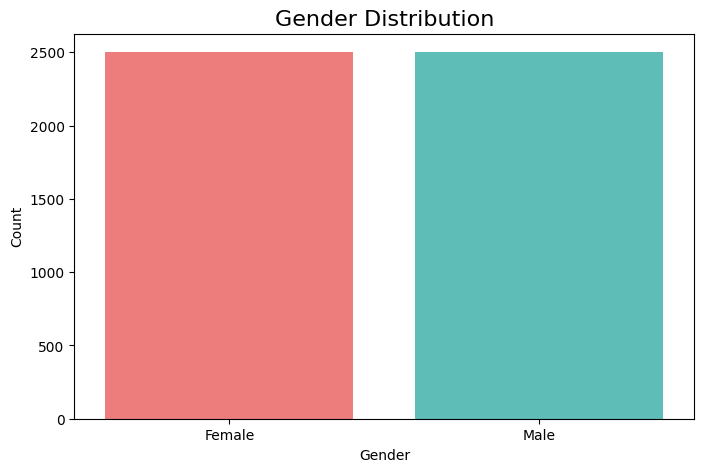

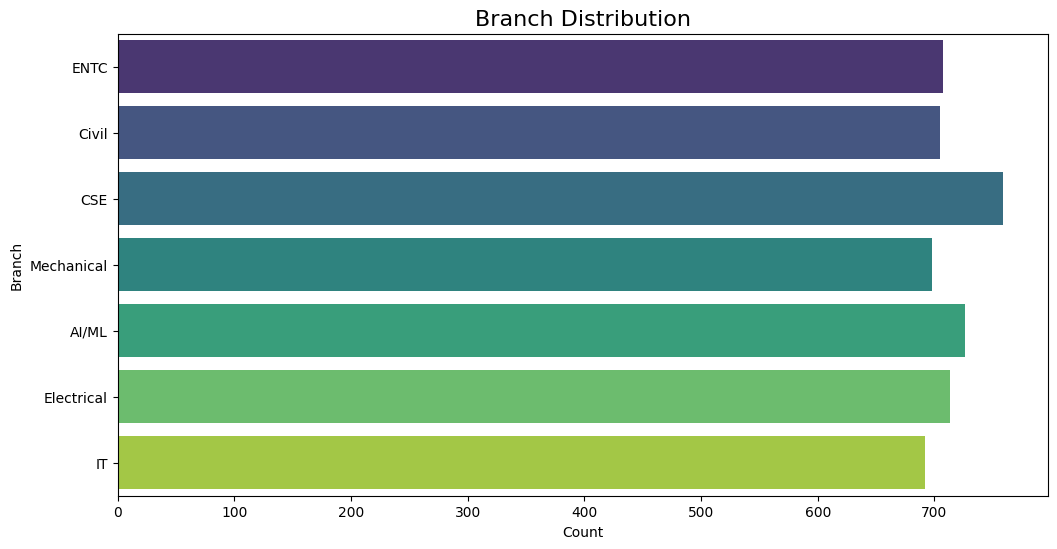

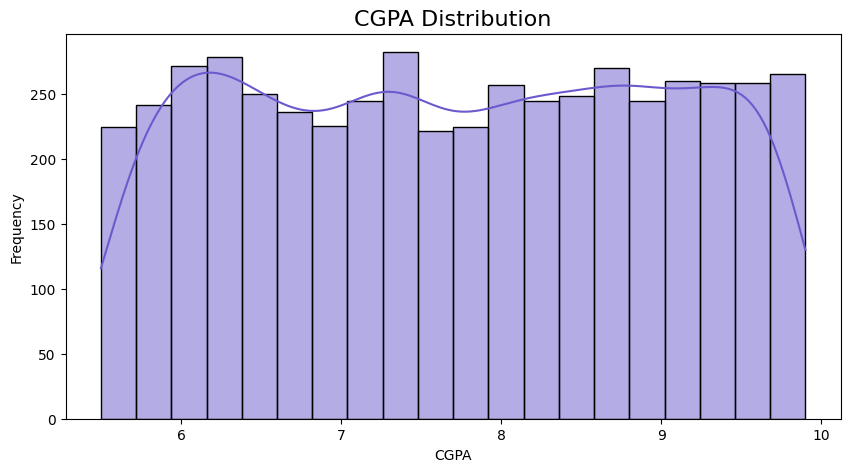

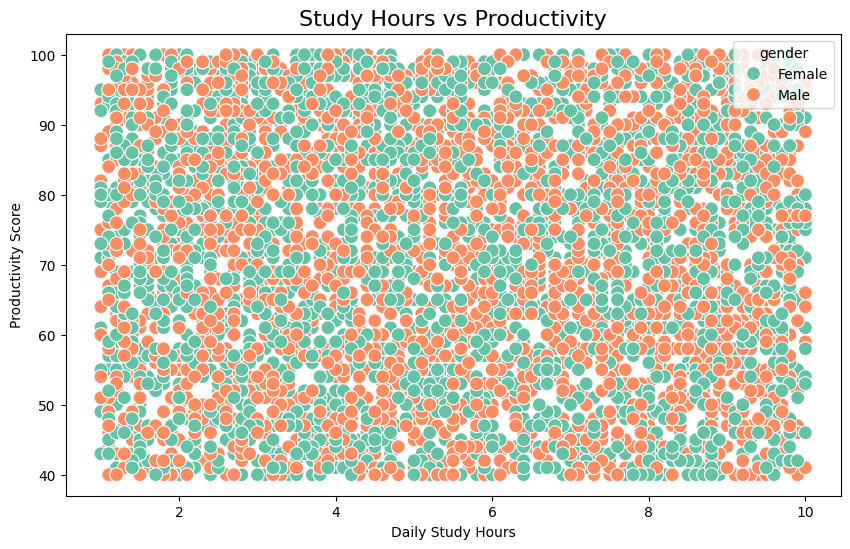

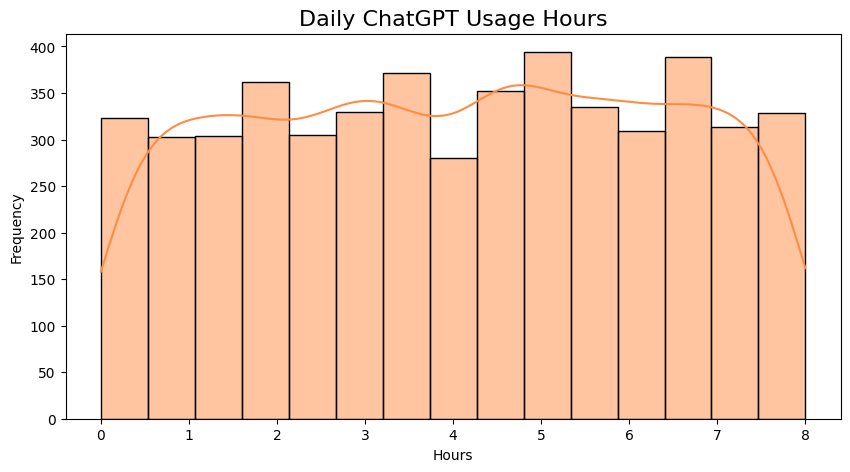

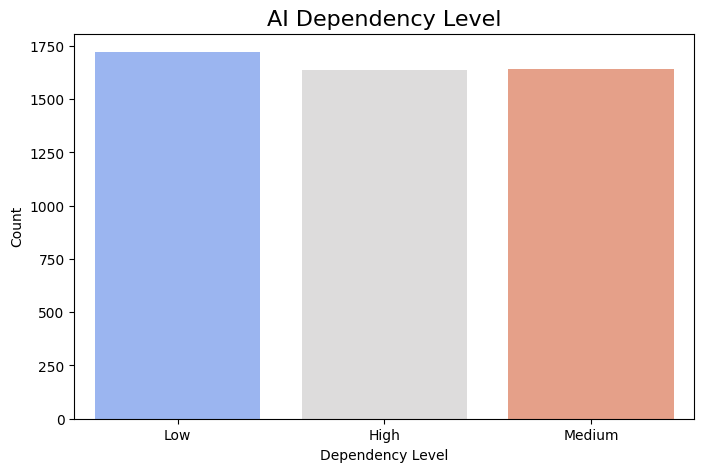

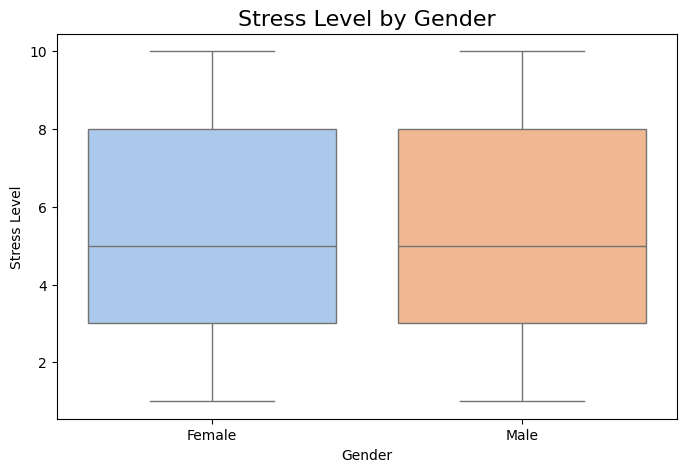

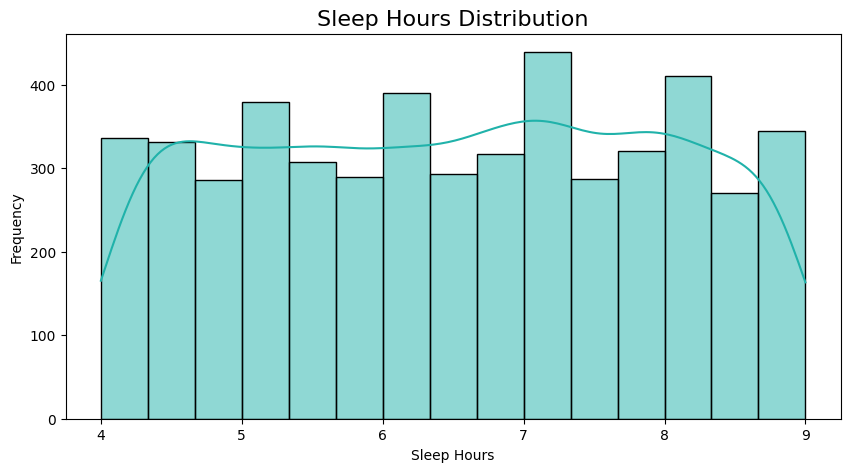

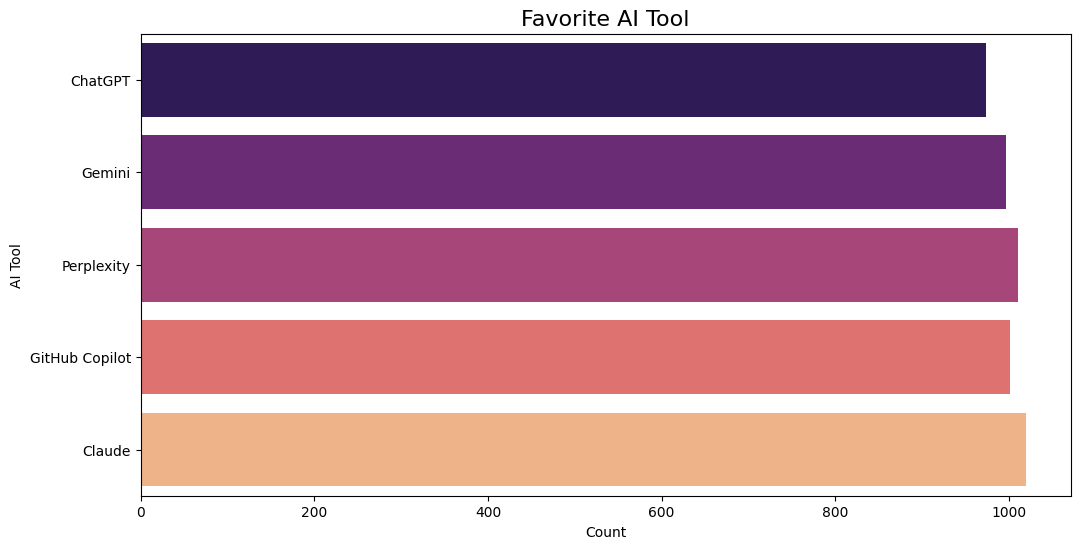

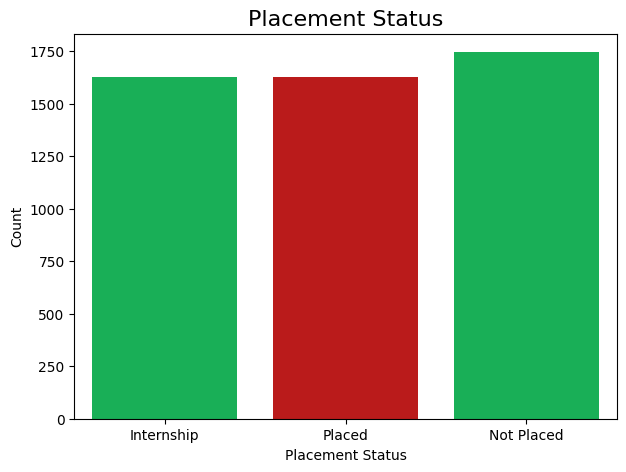

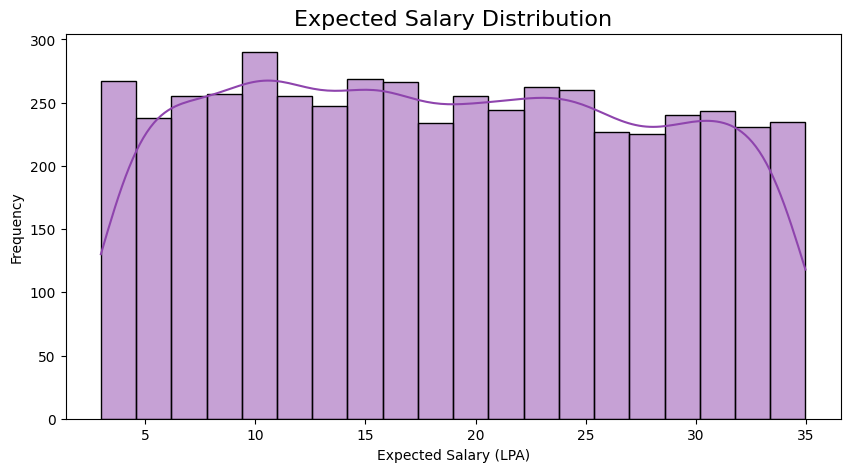

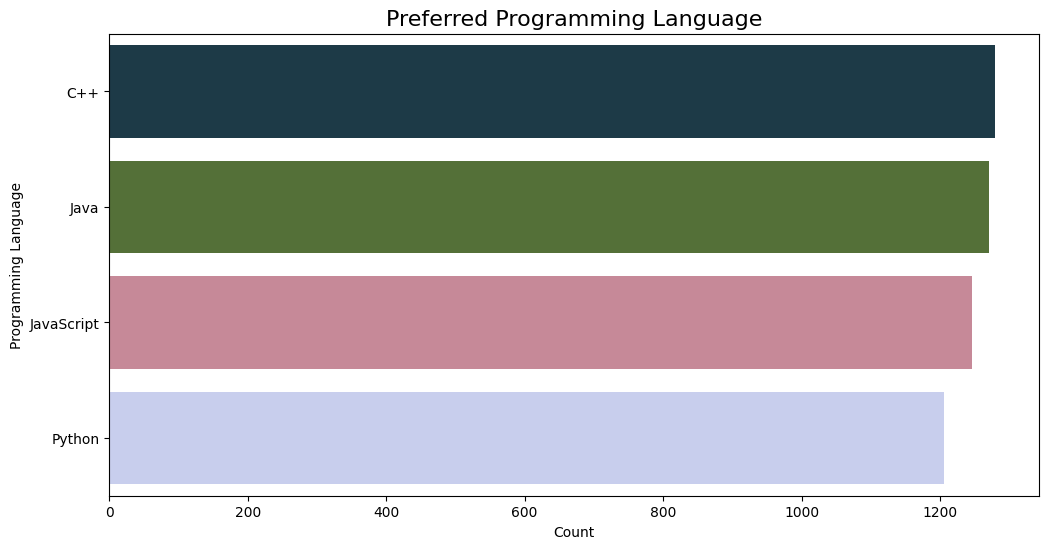

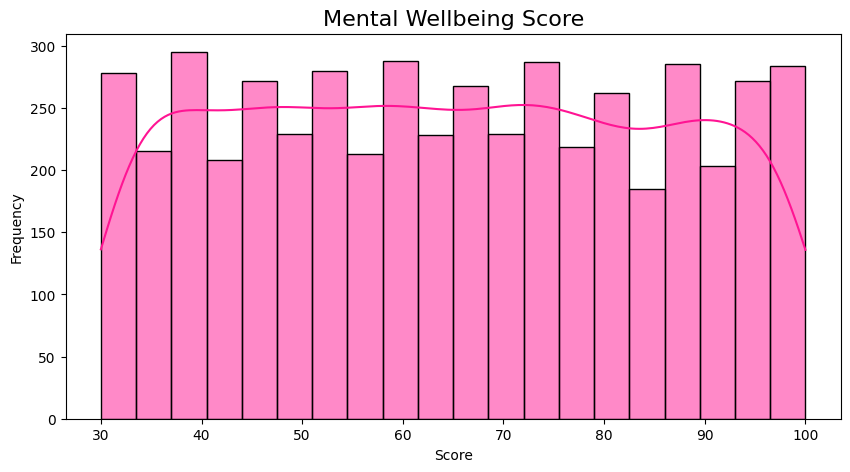

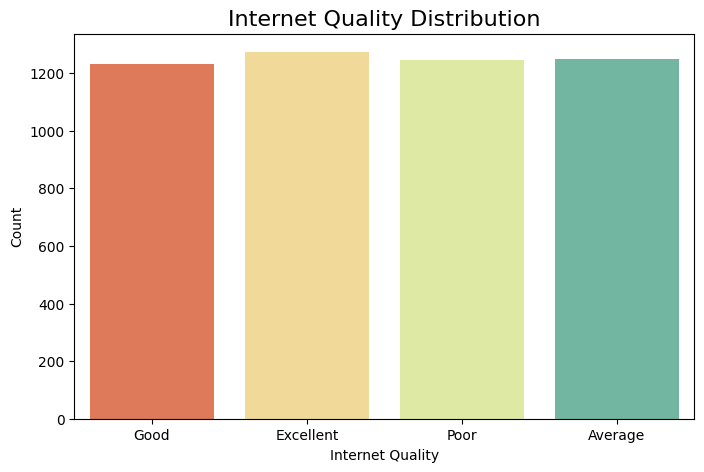

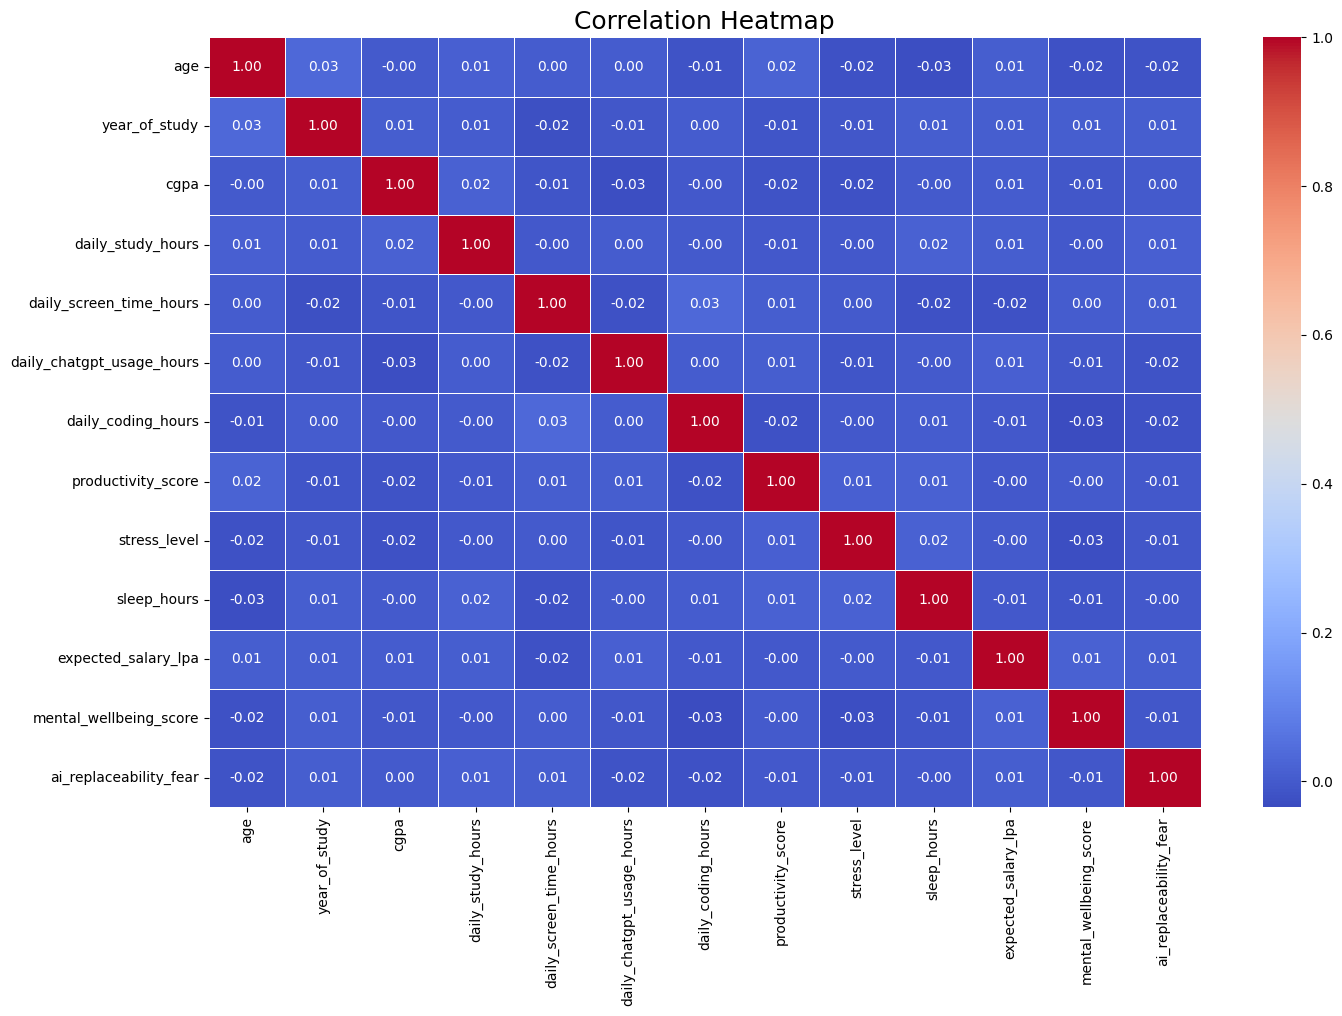

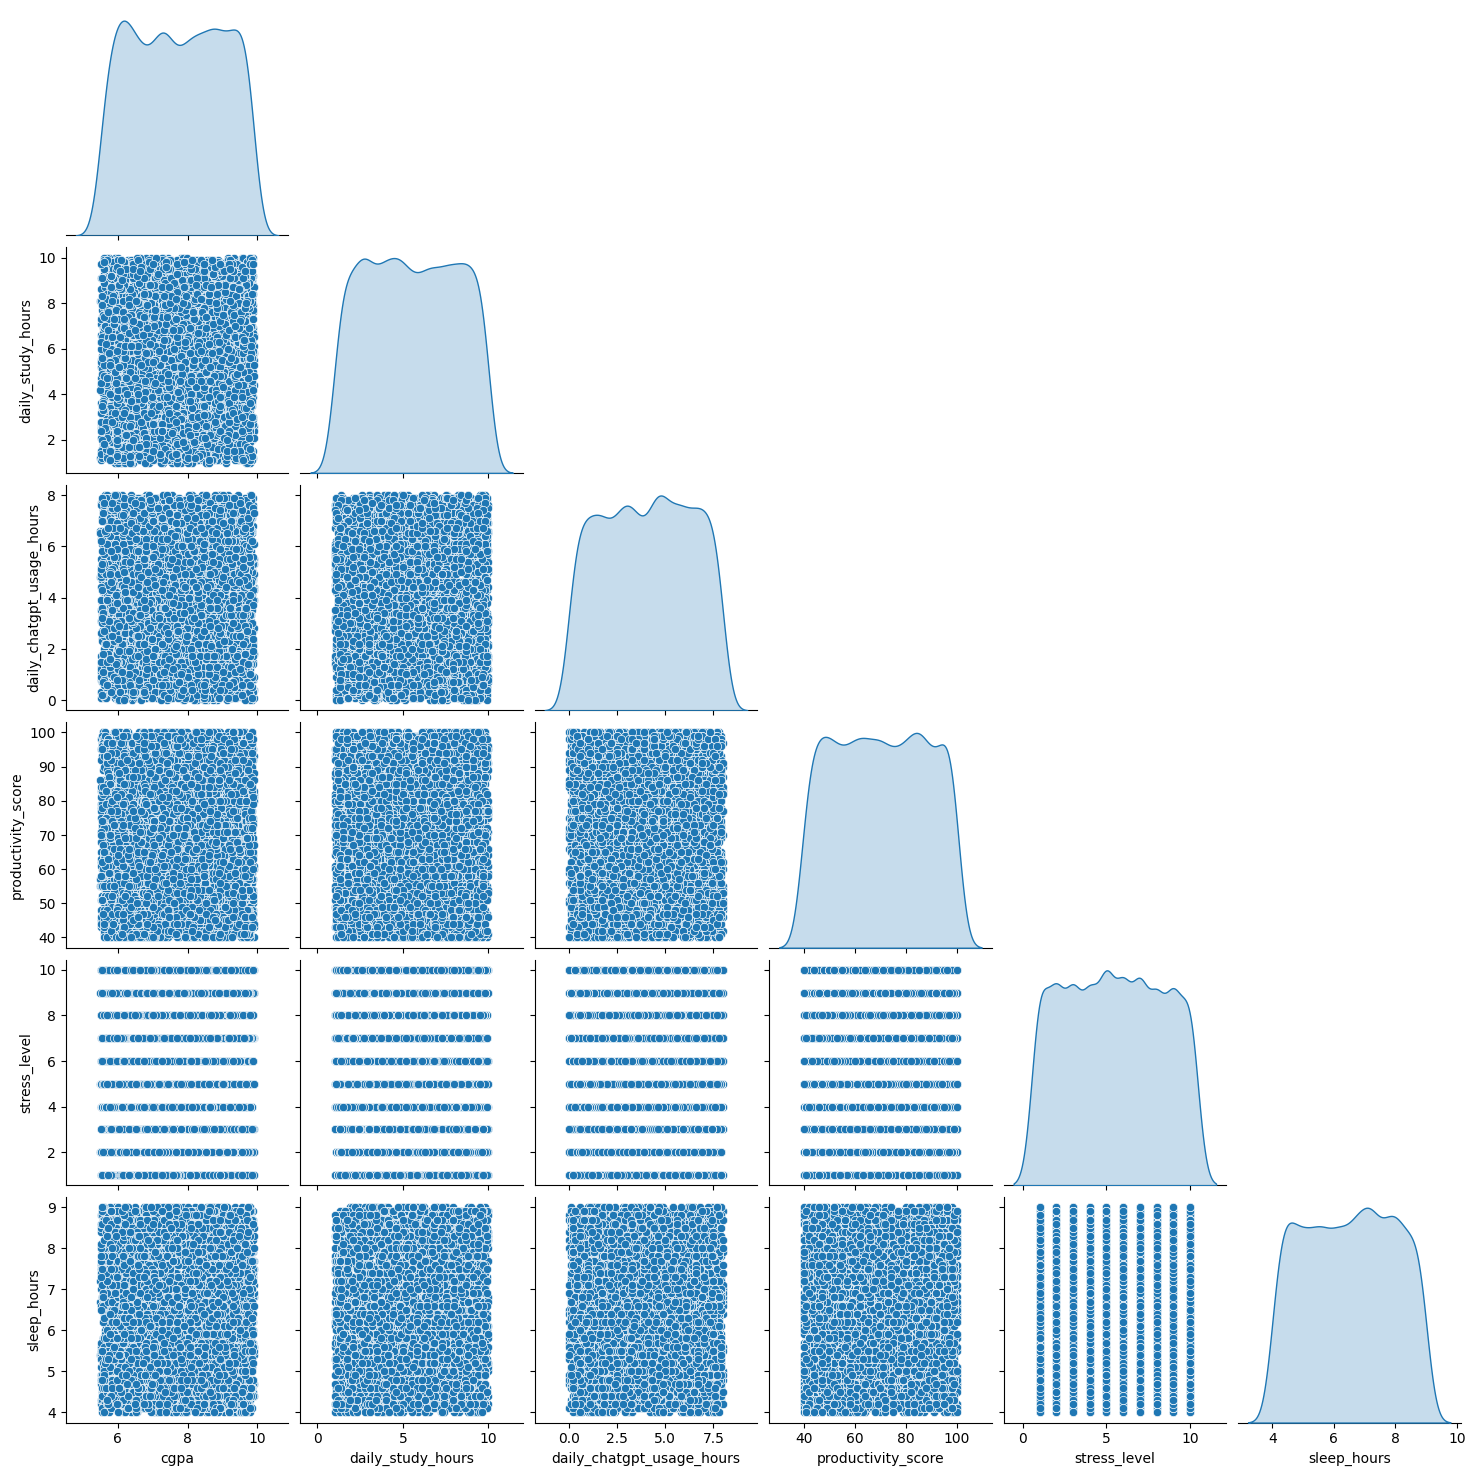

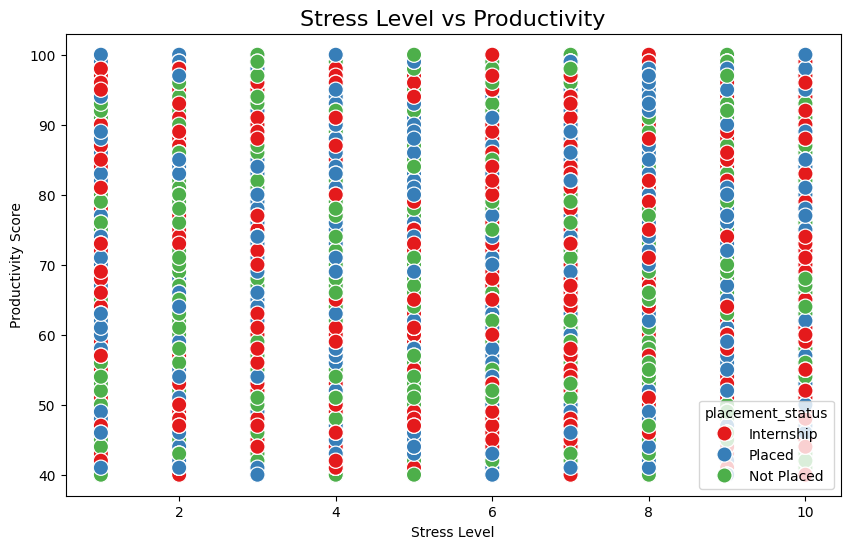

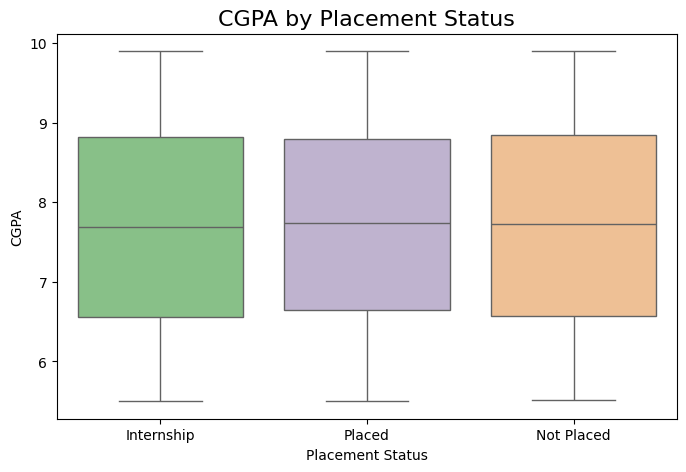

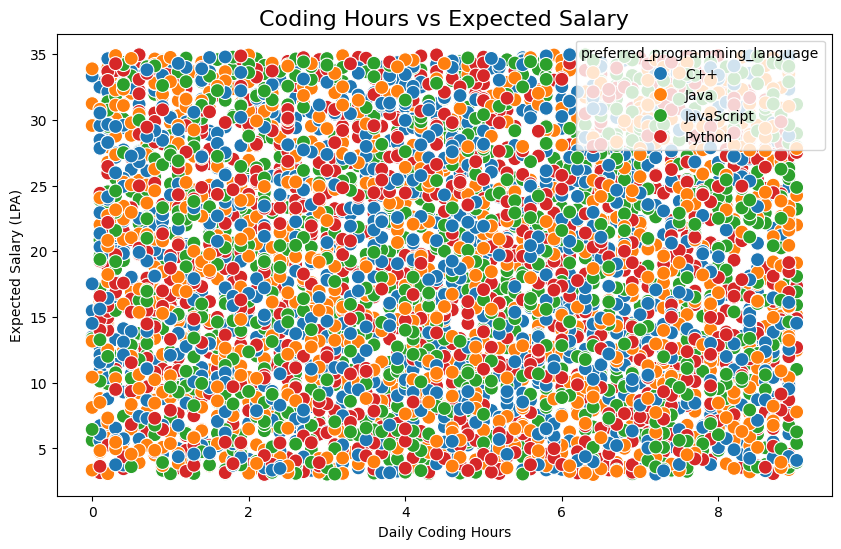

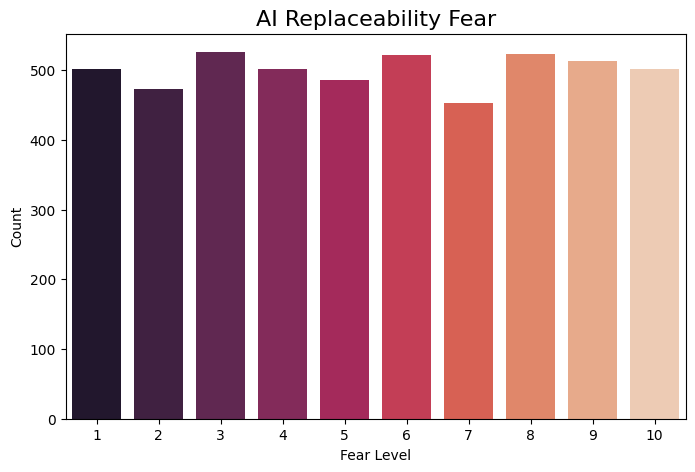

In [13]:
# ------------------------------------------------
# 1. Gender Distribution
# ------------------------------------------------
plt.figure(figsize=(8,5))
sns.countplot(
    x='gender',
    data=df,
    palette=['#FF6B6B', '#4ECDC4', '#FFD93D']
)
plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------
# 2. Branch Distribution
# ------------------------------------------------
plt.figure(figsize=(12,6))
sns.countplot(
    y='branch',
    data=df,
    palette='viridis'
)
plt.title("Branch Distribution", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Branch")
plt.show()

# ------------------------------------------------
# 3. CGPA Distribution
# ------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(
    df['cgpa'],
    bins=20,
    kde=True,
    color='#6A5ACD'
)
plt.title("CGPA Distribution", fontsize=16)
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------
# 4. Daily Study Hours vs Productivity Score
# ------------------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='daily_study_hours',
    y='productivity_score',
    hue='gender',
    palette='Set2',
    s=100,
    data=df
)
plt.title("Study Hours vs Productivity", fontsize=16)
plt.xlabel("Daily Study Hours")
plt.ylabel("Productivity Score")
plt.show()

# ------------------------------------------------
# 5. ChatGPT Usage Distribution
# ------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(
    df['daily_chatgpt_usage_hours'],
    bins=15,
    kde=True,
    color='#FF8C42'
)
plt.title("Daily ChatGPT Usage Hours", fontsize=16)
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------
# 6. AI Dependency Level Count
# ------------------------------------------------
plt.figure(figsize=(8,5))
sns.countplot(
    x='ai_dependency_level',
    data=df,
    palette='coolwarm'
)
plt.title("AI Dependency Level", fontsize=16)
plt.xlabel("Dependency Level")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------
# 7. Stress Level by Gender
# ------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(
    x='gender',
    y='stress_level',
    data=df,
    palette='pastel'
)
plt.title("Stress Level by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Stress Level")
plt.show()

# ------------------------------------------------
# 8. Sleep Hours Distribution
# ------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(
    df['sleep_hours'],
    bins=15,
    kde=True,
    color='#20B2AA'
)
plt.title("Sleep Hours Distribution", fontsize=16)
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------
# 9. Favorite AI Tool Usage
# ------------------------------------------------
plt.figure(figsize=(12,6))
sns.countplot(
    y='favorite_ai_tool',
    data=df,
    palette='magma'
)
plt.title("Favorite AI Tool", fontsize=16)
plt.xlabel("Count")
plt.ylabel("AI Tool")
plt.show()

# ------------------------------------------------
# 10. Placement Status Distribution
# ------------------------------------------------
plt.figure(figsize=(7,5))
sns.countplot(
    x='placement_status',
    data=df,
    palette=['#00C853', '#D50000']
)
plt.title("Placement Status", fontsize=16)
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------
# 11. Expected Salary Distribution
# ------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(
    df['expected_salary_lpa'],
    bins=20,
    kde=True,
    color='#8E44AD'
)
plt.title("Expected Salary Distribution", fontsize=16)
plt.xlabel("Expected Salary (LPA)")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------
# 12. Programming Language Preference
# ------------------------------------------------
plt.figure(figsize=(12,6))
sns.countplot(
    y='preferred_programming_language',
    data=df,
    palette='cubehelix'
)
plt.title("Preferred Programming Language", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Programming Language")
plt.show()

# ------------------------------------------------
# 13. Mental Wellbeing Score Distribution
# ------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(
    df['mental_wellbeing_score'],
    bins=20,
    kde=True,
    color='#FF1493'
)
plt.title("Mental Wellbeing Score", fontsize=16)
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------
# 14. Internet Quality Distribution
# ------------------------------------------------
plt.figure(figsize=(8,5))
sns.countplot(
    x='internet_quality',
    data=df,
    palette='Spectral'
)
plt.title("Internet Quality Distribution", fontsize=16)
plt.xlabel("Internet Quality")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------
# 15. Correlation Heatmap
# ------------------------------------------------
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# ------------------------------------------------
# 16. Pairplot for Important Features
# ------------------------------------------------
selected_columns = [
    'cgpa',
    'daily_study_hours',
    'daily_chatgpt_usage_hours',
    'productivity_score',
    'stress_level',
    'sleep_hours'
]

sns.pairplot(
    df[selected_columns],
    diag_kind='kde',
    corner=True,
    palette='husl'
)

plt.show()

# ------------------------------------------------
# 17. Productivity vs Stress Level
# ------------------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='stress_level',
    y='productivity_score',
    hue='placement_status',
    palette='Set1',
    s=120,
    data=df
)
plt.title("Stress Level vs Productivity", fontsize=16)
plt.xlabel("Stress Level")
plt.ylabel("Productivity Score")
plt.show()

# ------------------------------------------------
# 18. CGPA by Placement Status
# ------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(
    x='placement_status',
    y='cgpa',
    data=df,
    palette='Accent'
)
plt.title("CGPA by Placement Status", fontsize=16)
plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.show()

# ------------------------------------------------
# 19. Coding Hours vs Salary Expectation
# ------------------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='daily_coding_hours',
    y='expected_salary_lpa',
    hue='preferred_programming_language',
    palette='tab10',
    s=100,
    data=df
)
plt.title("Coding Hours vs Expected Salary", fontsize=16)
plt.xlabel("Daily Coding Hours")
plt.ylabel("Expected Salary (LPA)")
plt.show()

# ------------------------------------------------
# 20. AI Replaceability Fear Distribution
# ------------------------------------------------
plt.figure(figsize=(8,5))
sns.countplot(
    x='ai_replaceability_fear',
    data=df,
    palette='rocket'
)
plt.title("AI Replaceability Fear", fontsize=16)
plt.xlabel("Fear Level")
plt.ylabel("Count")
plt.show()

## Feature engineering


TARGET DISTRIBUTION

placement_status
Not Placed    1746
Placed        1628
Internship    1626
Name: count, dtype: int64

Training Shape : (4000, 21)
Testing Shape  : (1000, 21)

Categorical Columns:

['gender', 'city', 'state', 'branch', 'favorite_ai_tool', 'ai_dependency_level', 'internet_quality', 'preferred_programming_language']

Numerical Columns:

['age', 'year_of_study', 'cgpa', 'daily_study_hours', 'daily_screen_time_hours', 'daily_chatgpt_usage_hours', 'daily_coding_hours', 'productivity_score', 'stress_level', 'sleep_hours', 'expected_salary_lpa', 'mental_wellbeing_score', 'ai_replaceability_fear']

MODEL : Logistic Regression

Accuracy Score : 0.3210

Classification Report:

              precision    recall  f1-score   support

  Internship       0.31      0.28      0.30       325
  Not Placed       0.34      0.45      0.39       349
      Placed       0.29      0.23      0.26       326

    accuracy                           0.32      1000
   macro avg       0.32      0.

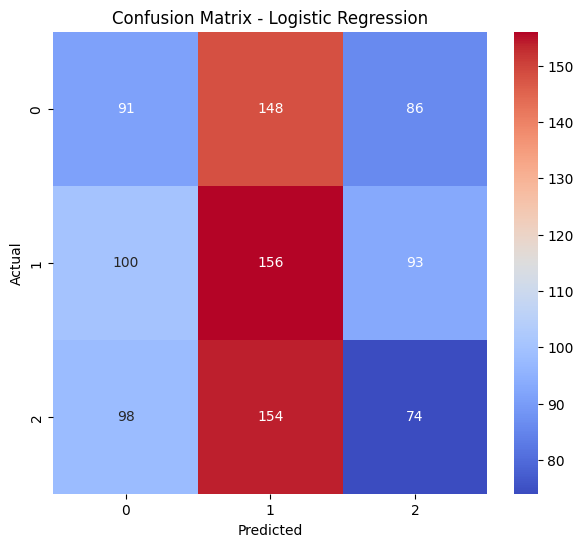

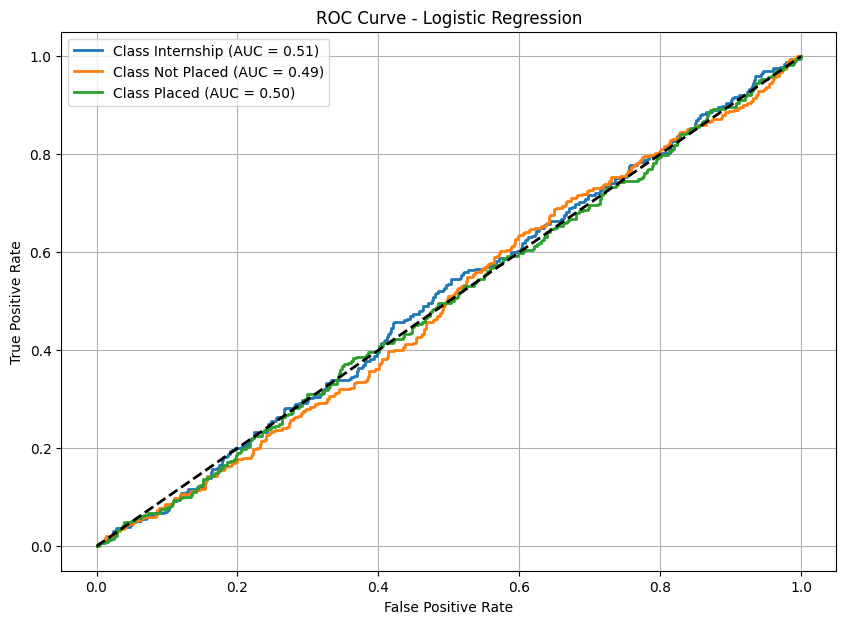


MODEL : Decision Tree

Accuracy Score : 0.3230

Classification Report:

              precision    recall  f1-score   support

  Internship       0.33      0.07      0.12       325
  Not Placed       0.34      0.50      0.40       349
      Placed       0.30      0.39      0.34       326

    accuracy                           0.32      1000
   macro avg       0.32      0.32      0.29      1000
weighted avg       0.32      0.32      0.29      1000



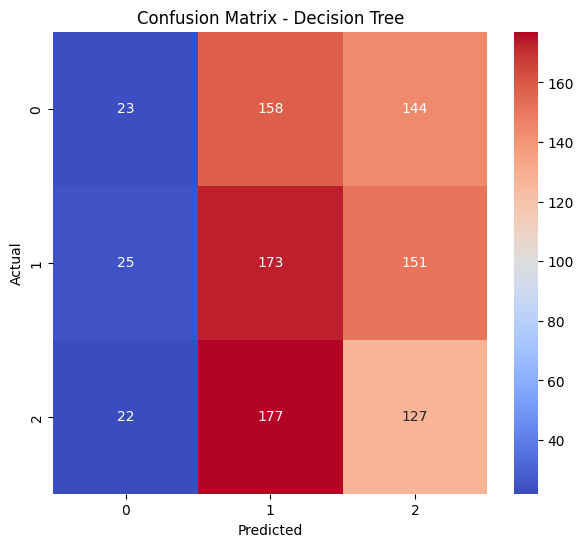

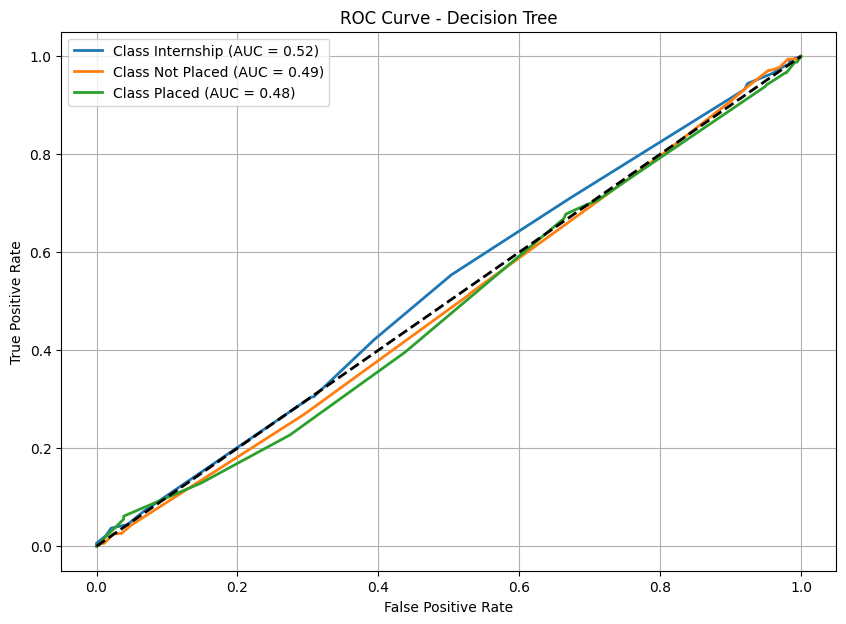


MODEL : Random Forest

Accuracy Score : 0.3140

Classification Report:

              precision    recall  f1-score   support

  Internship       0.32      0.29      0.30       325
  Not Placed       0.32      0.43      0.37       349
      Placed       0.29      0.22      0.25       326

    accuracy                           0.31      1000
   macro avg       0.31      0.31      0.31      1000
weighted avg       0.31      0.31      0.31      1000



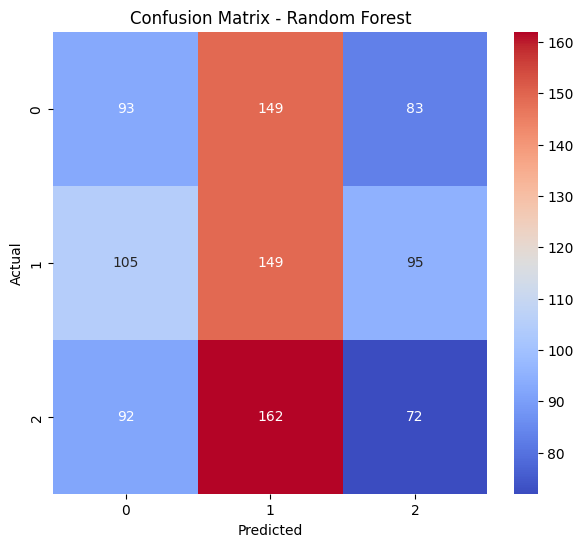

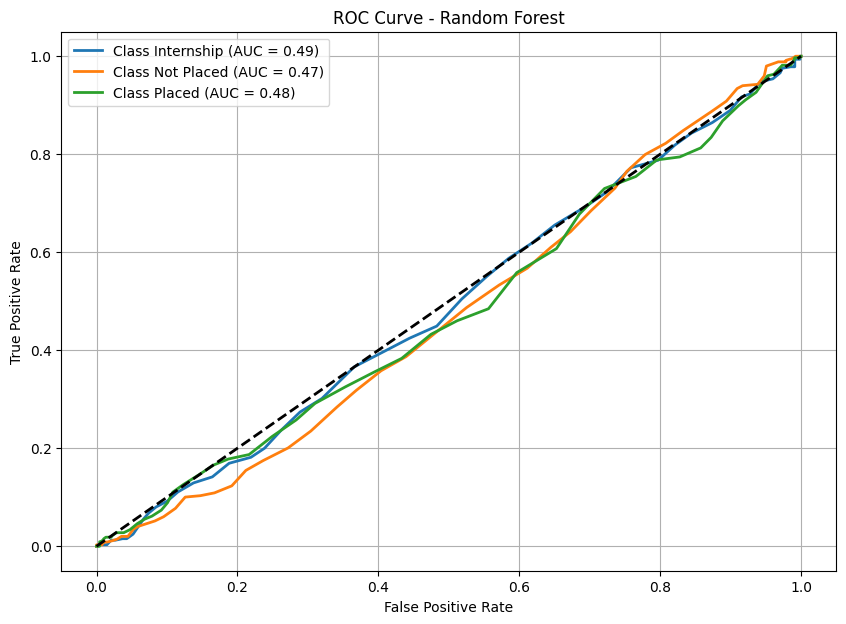


MODEL : Gradient Boosting

Accuracy Score : 0.3310

Classification Report:

              precision    recall  f1-score   support

  Internship       0.33      0.28      0.30       325
  Not Placed       0.34      0.42      0.37       349
      Placed       0.32      0.29      0.30       326

    accuracy                           0.33      1000
   macro avg       0.33      0.33      0.33      1000
weighted avg       0.33      0.33      0.33      1000



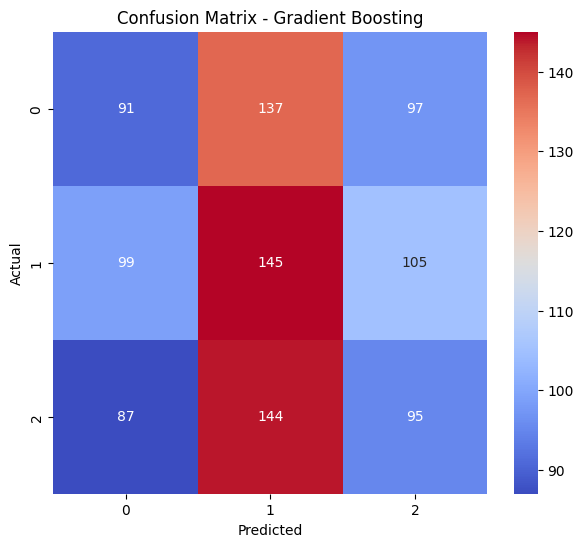

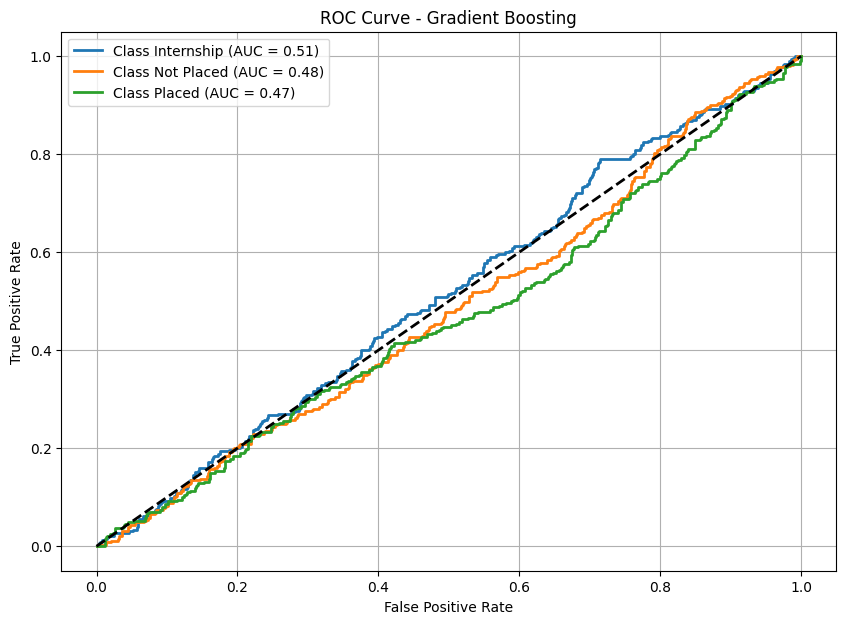


MODEL : KNN

Accuracy Score : 0.3440

Classification Report:

              precision    recall  f1-score   support

  Internship       0.34      0.45      0.39       325
  Not Placed       0.35      0.37      0.36       349
      Placed       0.33      0.21      0.26       326

    accuracy                           0.34      1000
   macro avg       0.34      0.34      0.34      1000
weighted avg       0.34      0.34      0.34      1000



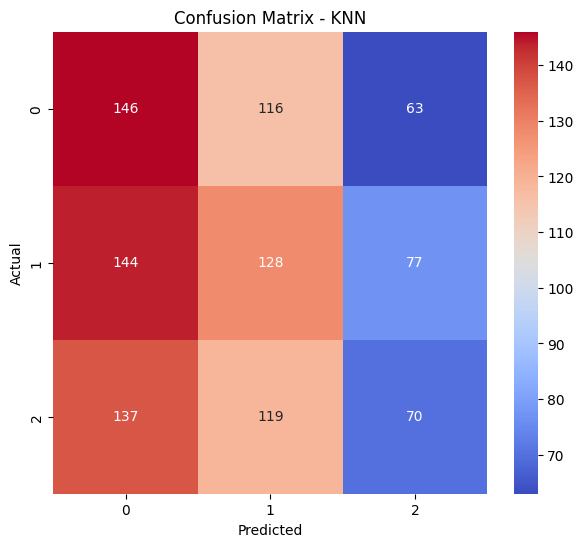

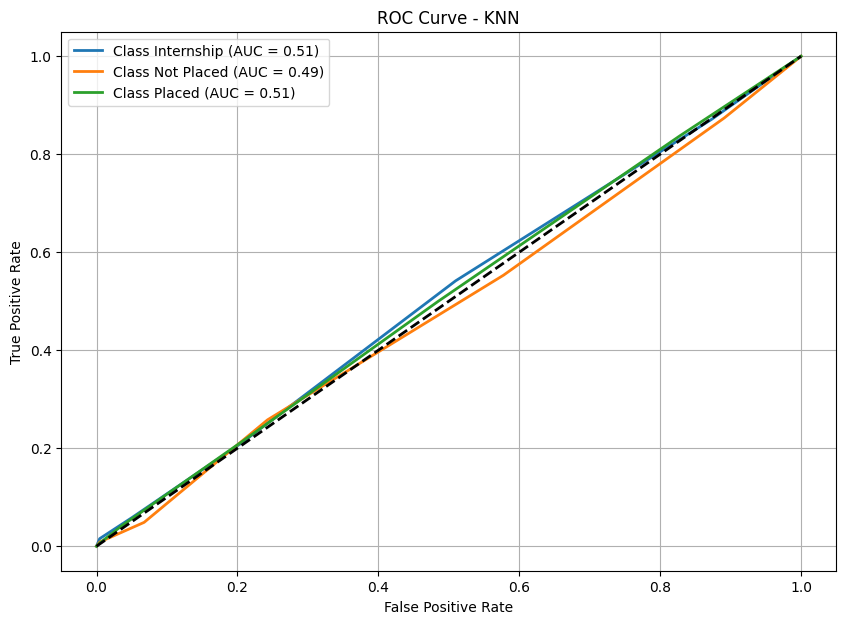


MODEL : SVM

Accuracy Score : 0.3580

Classification Report:

              precision    recall  f1-score   support

  Internship       0.37      0.20      0.26       325
  Not Placed       0.36      0.84      0.50       349
      Placed       0.00      0.00      0.00       326

    accuracy                           0.36      1000
   macro avg       0.24      0.35      0.25      1000
weighted avg       0.24      0.36      0.26      1000



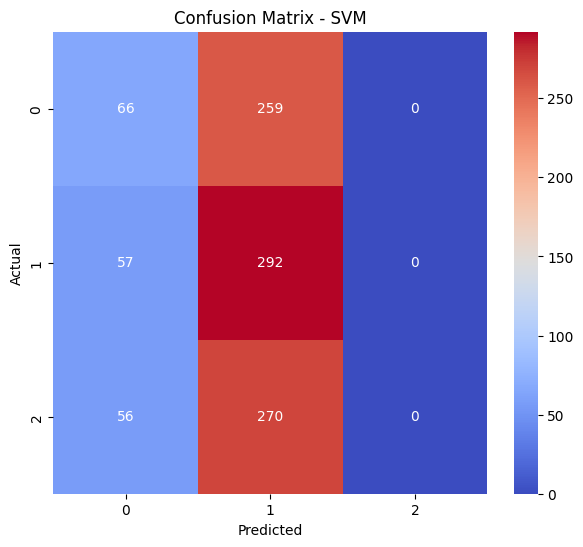

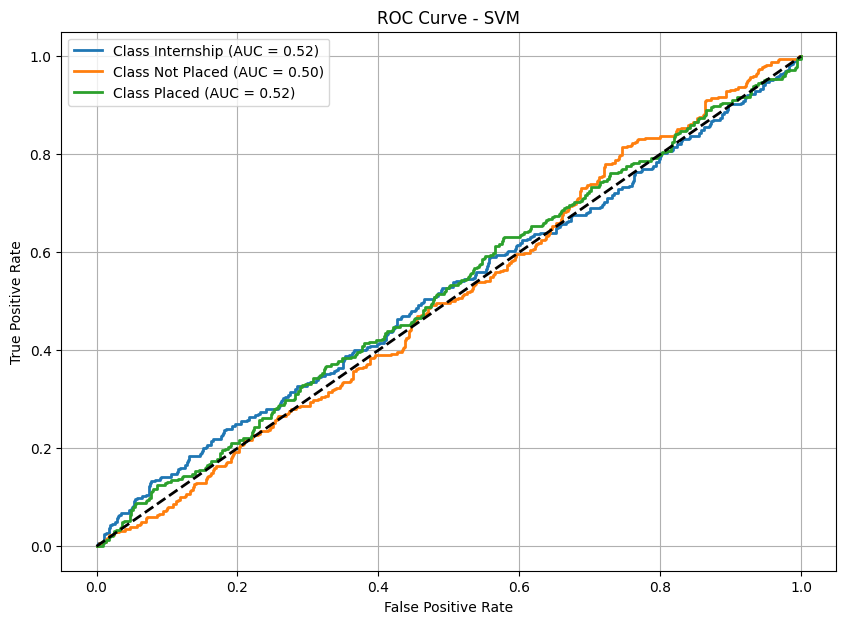


MODEL : Naive Bayes

Accuracy Score : 0.3380

Classification Report:

              precision    recall  f1-score   support

  Internship       0.31      0.31      0.31       325
  Not Placed       0.37      0.41      0.39       349
      Placed       0.33      0.29      0.31       326

    accuracy                           0.34      1000
   macro avg       0.34      0.34      0.34      1000
weighted avg       0.34      0.34      0.34      1000



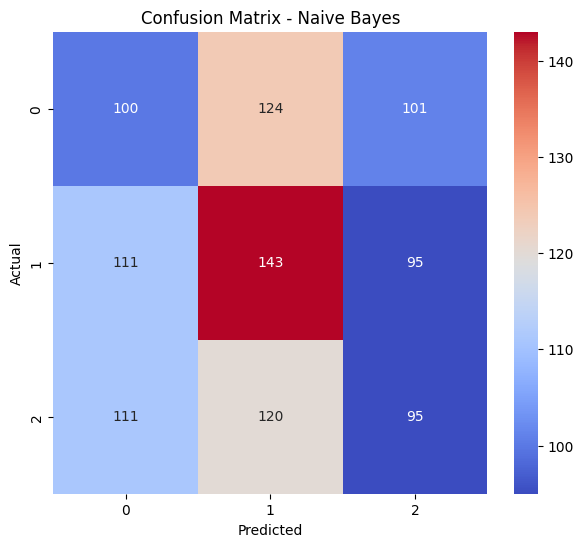

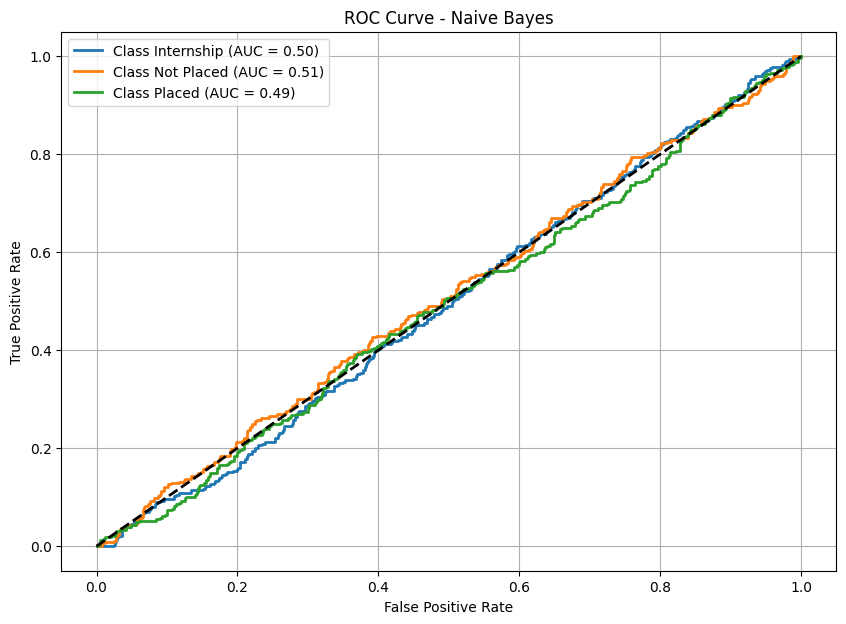


MODEL ACCURACY COMPARISON

                 Model  Accuracy
5                  SVM     0.358
4                  KNN     0.344
6          Naive Bayes     0.338
3    Gradient Boosting     0.331
1        Decision Tree     0.323
0  Logistic Regression     0.321
2        Random Forest     0.314


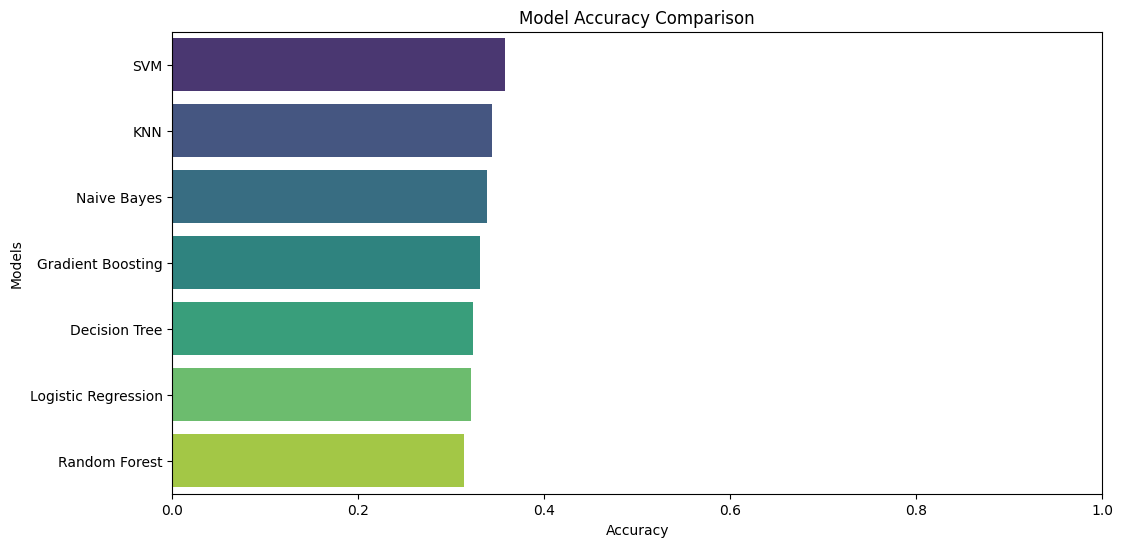


BEST MODEL

Best Model : SVM
Best Accuracy : 0.3580

FEATURE IMPORTANCE

                                Feature  Importance
10                  expected_salary_lpa    0.061482
2                                  cgpa    0.061066
4               daily_screen_time_hours    0.058426
6                    daily_coding_hours    0.057262
5             daily_chatgpt_usage_hours    0.056962
3                     daily_study_hours    0.056823
11               mental_wellbeing_score    0.056521
7                    productivity_score    0.055372
9                           sleep_hours    0.054530
0                                   age    0.041972
8                          stress_level    0.039274
12               ai_replaceability_fear    0.039193
1                         year_of_study    0.024583
43             ai_dependency_level_High    0.010006
44              ai_dependency_level_Low    0.009967
51  preferred_programming_language_Java    0.009833
50   preferred_programming_language_C++   

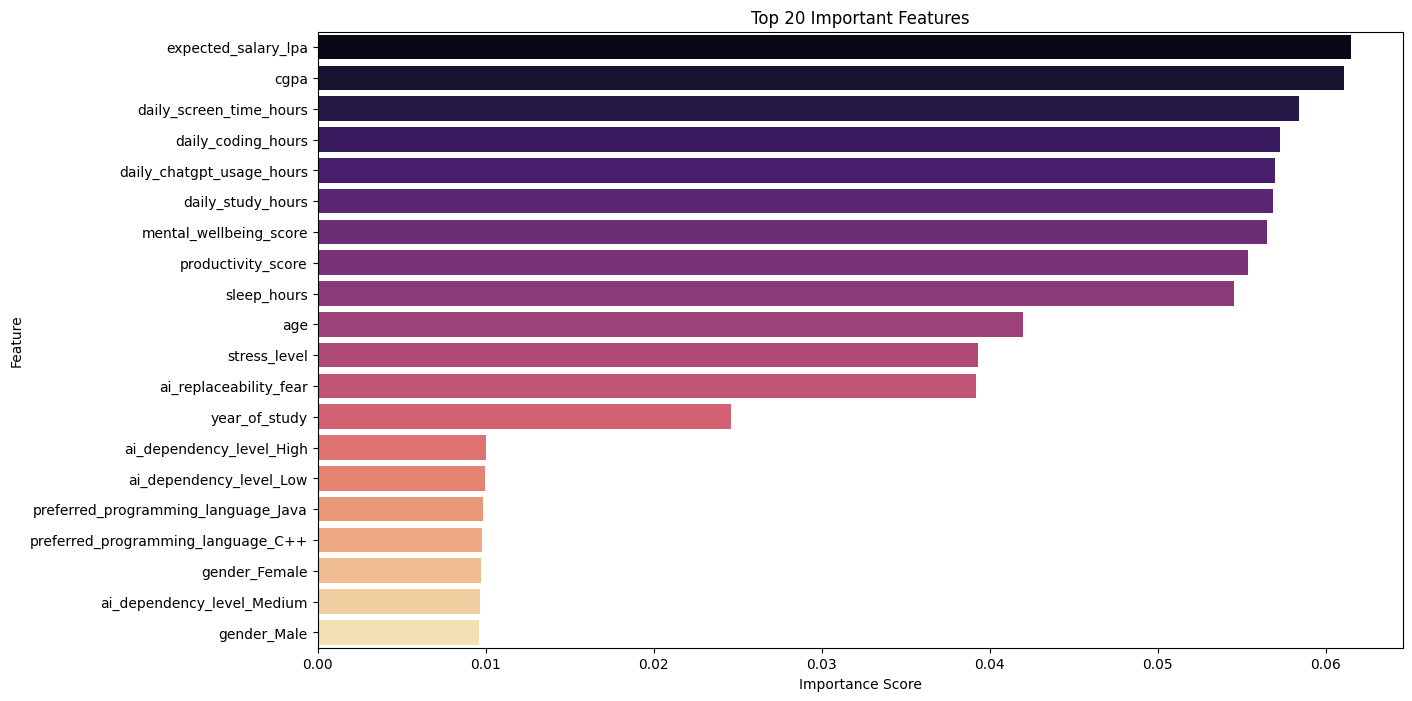


MACHINE LEARNING PIPELINE COMPLETED


In [14]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)



target_column = "placement_status"

# ============================================================
# DROP ID COLUMN
# ============================================================

if 'student_id' in df.columns:
    df.drop('student_id', axis=1, inplace=True)

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop(target_column, axis=1)

y = df[target_column]

# ============================================================
# TARGET DISTRIBUTION
# ============================================================

print("\n================================================")
print("TARGET DISTRIBUTION")
print("================================================\n")

print(y.value_counts())

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

# IMPORTANT:
# SPLIT BEFORE PREPROCESSING
# TO AVOID DATA LEAKAGE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ============================================================
# IDENTIFY CATEGORICAL & NUMERICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("\nCategorical Columns:\n")
print(categorical_columns)

print("\nNumerical Columns:\n")
print(numerical_columns)

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Numerical Pipeline
numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median'))

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(handle_unknown='ignore'))

])

# Column Transformer
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, numerical_columns),

        ('cat', categorical_transformer, categorical_columns)

    ]

)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True
    ),

    "Naive Bayes": GaussianNB()

}

# ============================================================
# STORE ACCURACY
# ============================================================

accuracy_results = {}

# ============================================================
# MULTICLASS ROC CLASSES
# ============================================================

classes = np.unique(y)

# ============================================================
# TRAIN ALL MODELS
# ============================================================

for model_name, model in models.items():

    print("\n================================================")
    print(f"MODEL : {model_name}")
    print("================================================\n")

    # ========================================================
    # CREATE PIPELINE
    # ========================================================

    pipeline = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)

    ])

    # ========================================================
    # SPECIAL CASE FOR NAIVE BAYES
    # ========================================================

    if model_name == "Naive Bayes":

        # Transform Training Data
        X_train_processed = preprocessor.fit_transform(X_train)

        # Transform Testing Data
        X_test_processed = preprocessor.transform(X_test)

        # Convert Sparse Matrix to Dense
        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()

        if hasattr(X_test_processed, "toarray"):
            X_test_processed = X_test_processed.toarray()

        # Train Model
        model.fit(X_train_processed, y_train)

        # Predictions
        y_pred = model.predict(X_test_processed)

        # Probabilities
        y_prob = model.predict_proba(X_test_processed)

    else:

        # ====================================================
        # TRAIN MODEL
        # ====================================================

        pipeline.fit(X_train, y_train)

        # ====================================================
        # PREDICTIONS
        # ====================================================

        y_pred = pipeline.predict(X_test)

        # ====================================================
        # PROBABILITY PREDICTIONS
        # ====================================================

        y_prob = pipeline.predict_proba(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[model_name] = accuracy

    print(f"Accuracy Score : {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm'
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ========================================================
    # MULTICLASS ROC CURVE
    # ========================================================

    # Convert target into binary format
    y_test_bin = label_binarize(
        y_test,
        classes=classes
    )

    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(10,7))

    # ROC FOR EACH CLASS
    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'Class {classes[i]} (AUC = {roc_auc:.2f})'
        )

    # Random Guess Line
    plt.plot(
        [0,1],
        [0,1],
        linestyle='--',
        linewidth=2,
        color='black'
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {model_name}")

    plt.legend()

    plt.grid(True)

    plt.show()

# ============================================================
# ACCURACY COMPARISON
# ============================================================

accuracy_df = pd.DataFrame({

    'Model': accuracy_results.keys(),

    'Accuracy': accuracy_results.values()

})

accuracy_df = accuracy_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n================================================")
print("MODEL ACCURACY COMPARISON")
print("================================================\n")

print(accuracy_df)

# ============================================================
# ACCURACY BARPLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=accuracy_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Accuracy")

plt.ylabel("Models")

plt.xlim(0,1)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = accuracy_df.iloc[0]

print("\n================================================")
print("BEST MODEL")
print("================================================\n")

print(f"Best Model : {best_model['Model']}")

print(f"Best Accuracy : {best_model['Accuracy']:.4f}")

# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

print("\n================================================")
print("FEATURE IMPORTANCE")
print("================================================\n")

# Create Random Forest Pipeline
rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

# Train
rf_pipeline.fit(X_train, y_train)

# ============================================================
# GET FEATURE NAMES
# ============================================================

# Encoded categorical column names
encoded_columns = rf_pipeline.named_steps[
    'preprocessor'
].transformers_[1][1].named_steps[
    'encoder'
].get_feature_names_out(categorical_columns)

# Combine all features
all_features = numerical_columns + list(encoded_columns)

# ============================================================
# FEATURE IMPORTANCE VALUES
# ============================================================

feature_importance = rf_pipeline.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({

    'Feature': all_features,

    'Importance': feature_importance

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(importance_df)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='magma'
)

plt.title("Top 20 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n================================================")
print("MACHINE LEARNING PIPELINE COMPLETED")
print("================================================")

## Thank you...pls upvote!!!!!!!!!!